In [ ]:
# Step 1: Importing Required Libraries and Data Collection
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import re

# Text Preprocessing
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

# WordCloud
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**LOAD DATASET**

In [ ]:
df = pd.read_excel('P652-Dataset.xlsx')
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [ ]:
##Remove unwanted spaces
df.columns = df.columns.str.strip()

In [ ]:
print("\n--- DATA INFO ---")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None

Missing values:
title     0
rating    0
body      0
dtype: int64

Duplicate rows: 0


Numeric columns considered for outlier checking:
Index(['rating'], dtype='object')


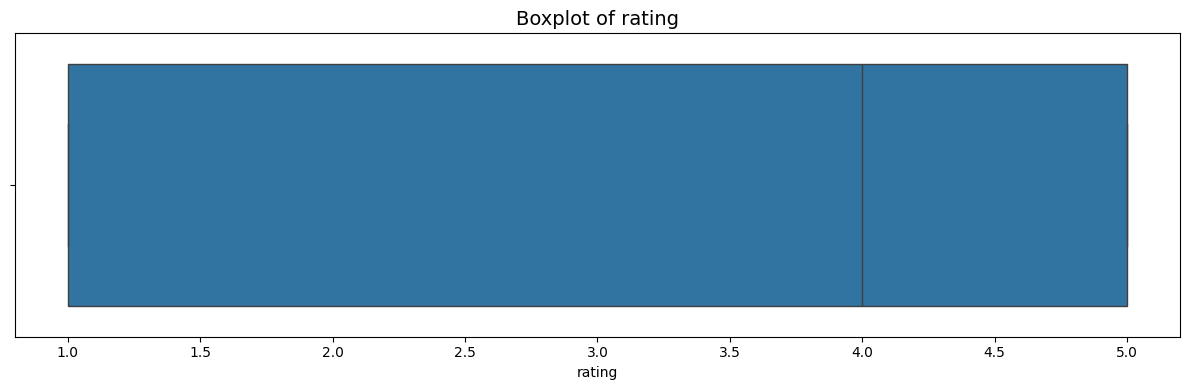

In [ ]:
# ================================
# OUTLIER CHECKING (BOXPLOTS)
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for outlier detection
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

print("Numeric columns considered for outlier checking:")
print(numeric_cols.columns)

# Plot boxplots for all numeric columns
plt.figure(figsize=(12, 4 * len(numeric_cols.columns)))

for i, col in enumerate(numeric_cols.columns, start=1):
    plt.subplot(len(numeric_cols.columns), 1, i)
    sns.boxplot(x=numeric_cols[col], orient='h')
    plt.title(f"Boxplot of {col}", fontsize=14)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df['text'] = df['title'].astype(str) + " " + df['body'].astype(str)

##Char count
df['char_count'] = df['text'].str.len()
##Word count
df['word_count'] = df['text'].str.split().str.len()

In [ ]:
df.head()

,title,rating,body,text,char_count,word_count
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,76,10
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...,61,11
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",411,67
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,394,72
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,209,34


**Word Count Distribution**

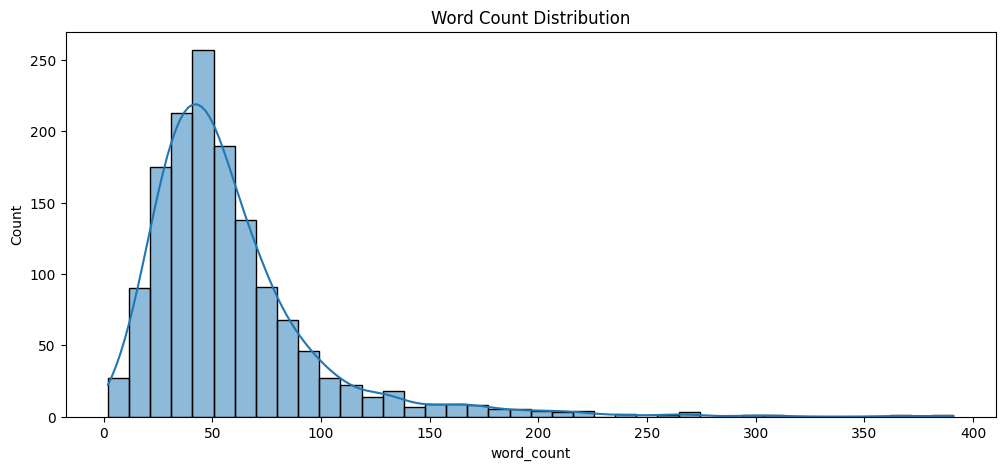

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.title("Word Count Distribution")
plt.show()

**Character Count Distribution**

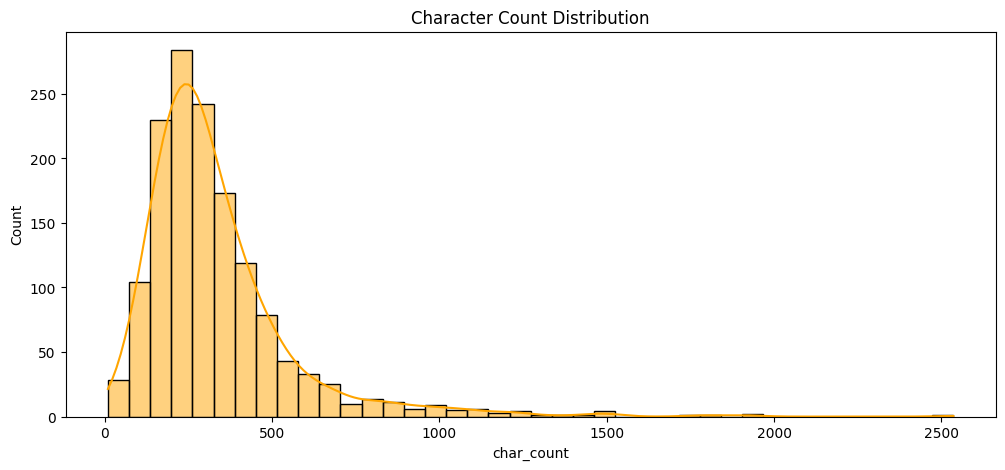

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(df['char_count'], bins=40, kde=True, color='orange')
plt.title("Character Count Distribution")
plt.show()

In [ ]:
def contains_url(text):
    return bool(re.search(r'http\S+|www\S+', text))

def contains_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emojis
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)
    return bool(emoji_pattern.search(text))

df['has_url'] = df['text'].apply(contains_url)
df['has_emoji'] = df['text'].apply(contains_emoji)

print("Rows with URLs:", df['has_url'].sum())
print("Rows with Emojis:", df['has_emoji'].sum())

Rows with URLs: 2
Rows with Emojis: 106


**Cleaning Text Data**

In [ ]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)      # Remove HTML
    text = re.sub(r'[^\w\s]', '', text)    # Remove punctuation
    text = re.sub(r'\d+', '', text)        # Remove numbers
    text = text.lower()                    # Lowercase
    stop_words = set(stopwords.words('english'))
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

df['clean_words'] = df['text'].apply(clean_text)

print(df['clean_words'].head())

0    horrible product disappointed overall performa...
1     camera quality like megapixel camera quality low
2    overall got mobile launch datebattery must app...
3    big doesnt work ghz wifi frequency ghz old sch...
4    put money somewhere else worth buyingfaulty so...
Name: clean_words, dtype: object


**Unigrams**

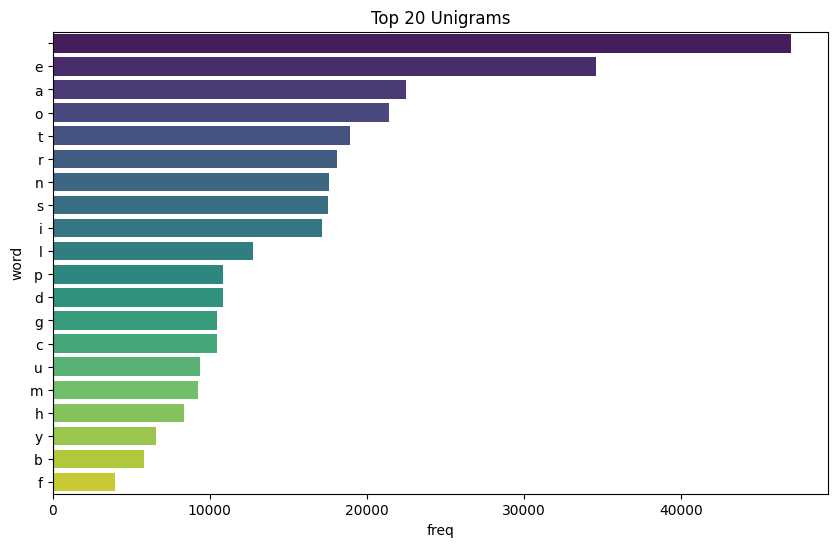

In [ ]:
unigrams = Counter([w for words in df['clean_words'] for w in words]).most_common(20)

uni_df = pd.DataFrame(unigrams, columns=['word','freq'])
plt.figure(figsize=(10,6))
sns.barplot(x='freq', y='word', data=uni_df, palette='viridis')
plt.title("Top 20 Unigrams")
plt.show()

**Bigrams**

In [ ]:
bigrams = Counter([bg for words in df['clean_words']
                   for bg in ngrams(words, 2)]).most_common(20)

print("Top Bigrams:", bigrams[:10])

Top Bigrams: [(('e', ' '), 9646), (('e', 'r'), 6258), (('t', ' '), 5646), ((' ', 'p'), 5560), (('o', 'n'), 5253), (('y', ' '), 5145), (('d', ' '), 4764), (('i', 'n'), 4575), ((' ', 's'), 4418), (('n', 'g'), 4308)]


**Trigrams**

In [ ]:
trigrams = Counter([tg for words in df['clean_words']
                   for tg in ngrams(words, 3)]).most_common(20)

print("Top Trigrams:", trigrams[:10])

Top Trigrams: [(('n', 'g', ' '), 3210), (('i', 'n', 'g'), 2851), (('o', 'n', 'e'), 2792), (('n', 'e', ' '), 2269), (('p', 'h', 'o'), 2242), (('h', 'o', 'n'), 2179), ((' ', 'p', 'h'), 2078), (('e', 'd', ' '), 1825), (('e', 'r', 'a'), 1690), ((' ', 'p', 'r'), 1685)]


**Word Cloud**

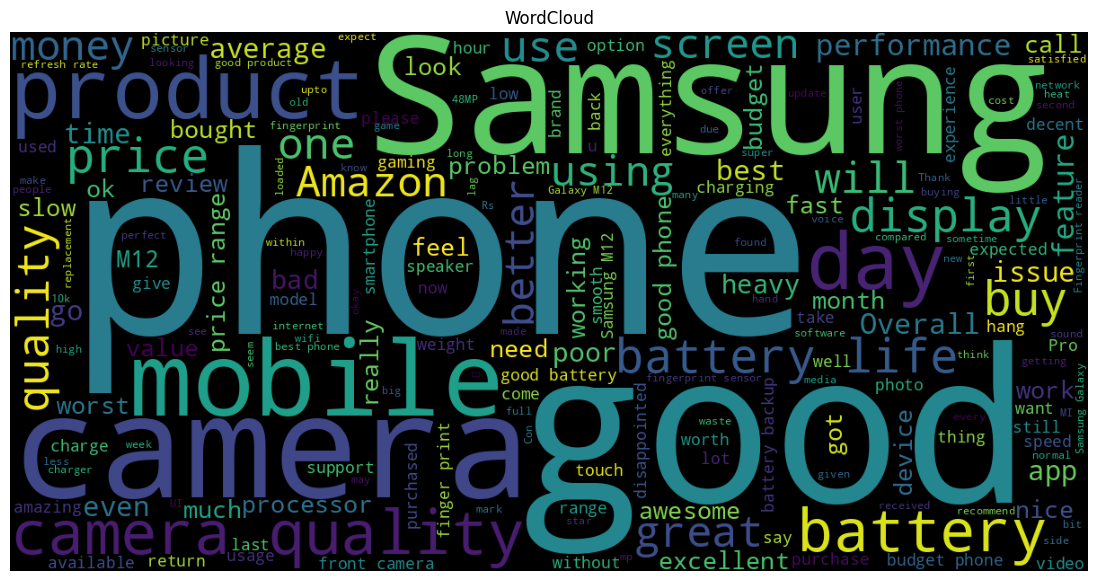

In [ ]:
all_words = " ".join(df['text'].astype(str))

wc = WordCloud(width=1200, height=600, background_color="black").generate(all_words)
plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud")
plt.show()

**Stop Word Analysis For Most Frequent StopWords**

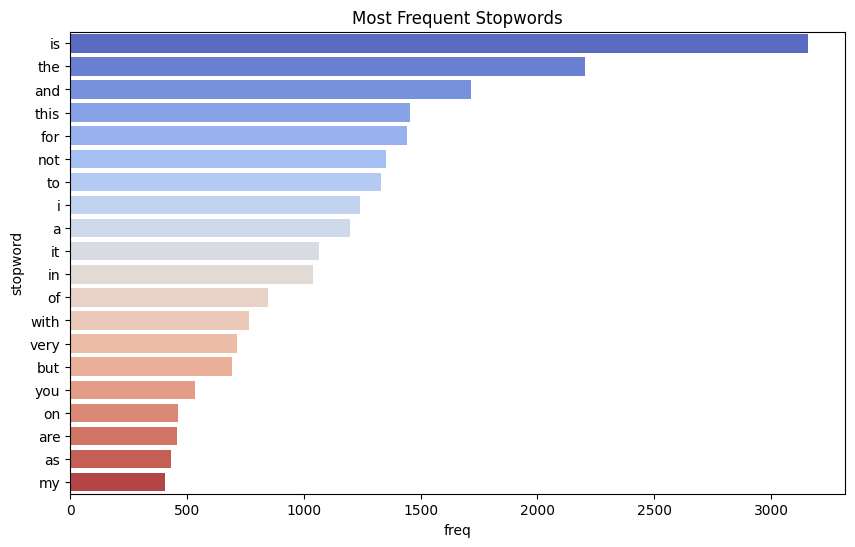

In [ ]:
stop_words = set(stopwords.words("english"))
stopword_list = []

for txt in df['text']:
    words = txt.lower().split()
    stopword_list.extend([w for w in words if w in stop_words])

stop_df = pd.DataFrame(Counter(stopword_list).most_common(20),
                       columns=['stopword','freq'])

plt.figure(figsize=(10,6))
sns.barplot(x='freq', y='stopword', data=stop_df, palette='coolwarm')
plt.title("Most Frequent Stopwords")
plt.show()

**CountPlot by Rating**

<Axes: xlabel='rating', ylabel='count'>

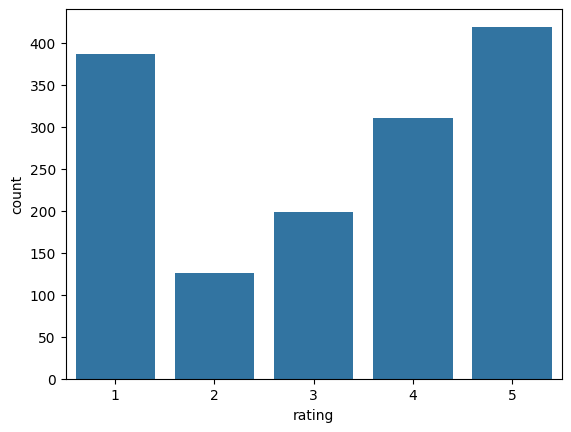

In [ ]:
sns.countplot(data=df,x='rating')

**Histogram For Charcount By Rating**



array([[<Axes: title={'center': '1'}>, <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>],
       [<Axes: title={'center': '5'}>, <Axes: >]], dtype=object)

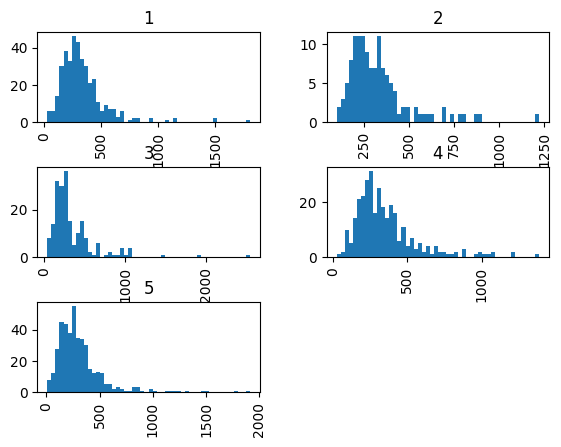

In [ ]:
df.hist('char_count',by='rating',bins=50)

**Histogram For Wordcount By Rating**

array([[<Axes: title={'center': '1'}>, <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>],
       [<Axes: title={'center': '5'}>, <Axes: >]], dtype=object)

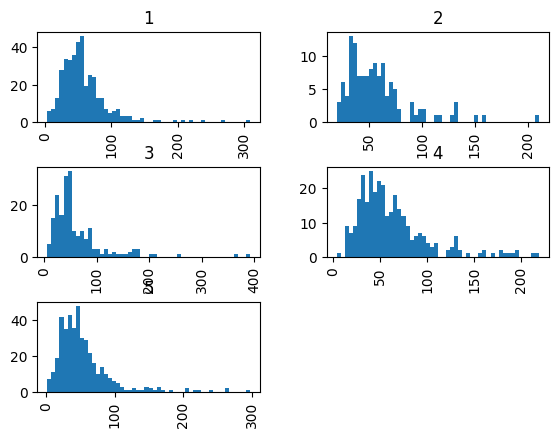

In [ ]:
df.hist('word_count',by='rating',bins=50)

**Label Sentiment by Rating**

In [ ]:
def label_sentiment(rating):
    if rating in [0, 1]:
        return "negative"
    elif rating == 2:
        return "neutral"
    elif rating in [3, 4, 5]: # Added 5 to positive sentiment
        return "positive"

df['sentiment'] = df['rating'].apply(label_sentiment)
print(df[['rating','sentiment']].head())
df.head()

   rating sentiment
0       1  negative
1       3  positive
2       4  positive
3       1  negative
4       1  negative


,title,rating,body,text,char_count,word_count,has_url,has_emoji,clean_words,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,76,10,False,False,horrible product disappointed overall performa...,negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...,61,11,False,False,camera quality like megapixel camera quality low,positive
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",411,67,False,False,overall got mobile launch datebattery must app...,positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,394,72,False,False,big doesnt work ghz wifi frequency ghz old sch...,negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,209,34,False,False,put money somewhere else worth buyingfaulty so...,negative


**Sentiment Distribution**

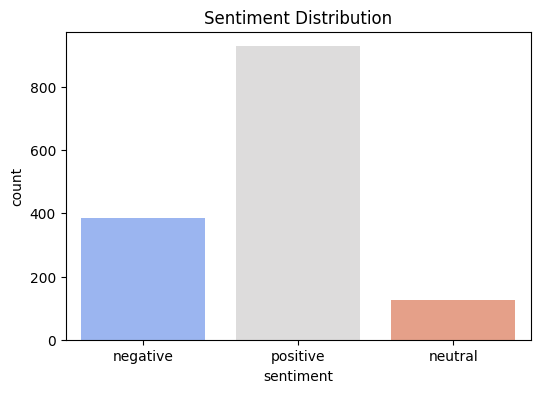

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', palette='coolwarm')
plt.title("Sentiment Distribution")
plt.show()

**Most Common Words**

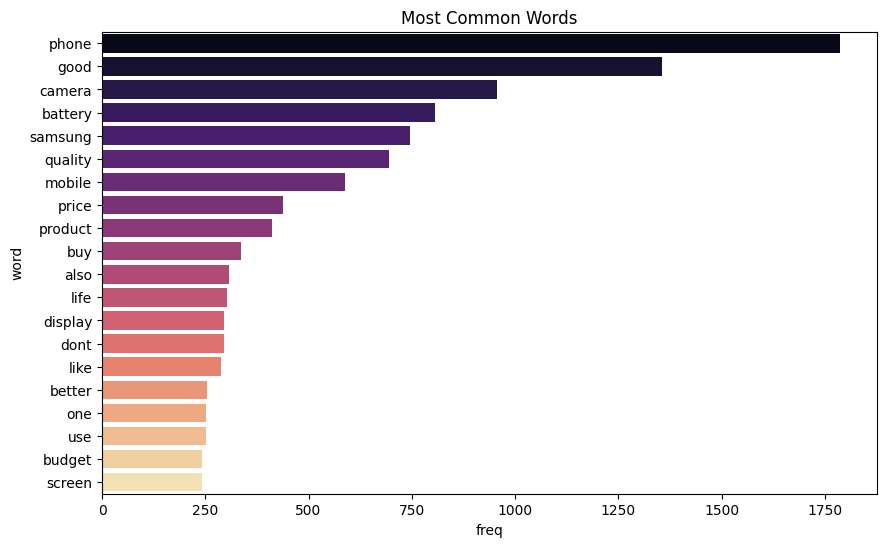

In [ ]:
words = " ".join(df['clean_words']).split()
word_counts = Counter(words)
df_common = pd.DataFrame(word_counts.most_common(20), columns=['word','freq'])

plt.figure(figsize=(10,6))
sns.barplot(data=df_common, x='freq', y='word', palette='magma')
plt.title("Most Common Words")
plt.show()

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

def get_pos(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc]

df['pos_tags'] = df['text'].apply(get_pos)

print(df['pos_tags'].head())

0    [(Horrible, ADJ), (product, NOUN), (Very, ADV)...
1    [(Camera, NOUN), (quality, NOUN), (is, AUX), (...
2    [(Overall, PROPN), (Got, VERB), (the, DET), (m...
3    [(A, DET), (big, ADJ), (no, INTJ), (from, ADP)...
4    [(Put, VERB), (your, PRON), (money, NOUN), (so...
Name: pos_tags, dtype: object


In [ ]:
numeric_features = df[['char_count','word_count']]

##Scale Numeric Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

In [ ]:
### TFIDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_words'])

In [ ]:
## Combine TFIDF + Numeric
from scipy.sparse import hstack
x = hstack((X,scaled_features))
y = df['sentiment']

In [ ]:
## Splitting the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

**MODEL BUILDING**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB

In [ ]:
# MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Linear SVM": LinearSVC(),
    "bnaive Bayes": BernoulliNB()

}

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    results[name] = (acc, pred)
    print(f"\n========== {name} ==========")
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))


========== Logistic Regression ==========
Accuracy: 0.7986111111111112
              precision    recall  f1-score   support

    negative       0.78      0.65      0.71        77
     neutral       0.00      0.00      0.00        25
    positive       0.80      0.97      0.88       186

    accuracy                           0.80       288
   macro avg       0.53      0.54      0.53       288
weighted avg       0.73      0.80      0.76       288


========== Linear SVM ==========
Accuracy: 0.8159722222222222
              precision    recall  f1-score   support

    negative       0.77      0.73      0.75        77
     neutral       0.50      0.04      0.07        25
    positive       0.84      0.96      0.89       186

    accuracy                           0.82       288
   macro avg       0.70      0.57      0.57       288
weighted avg       0.79      0.82      0.78       288


========== bnaive Bayes ==========
Accuracy: 0.7743055555555556
              precision    recall  f1-

**CONFUSION MATRIX**

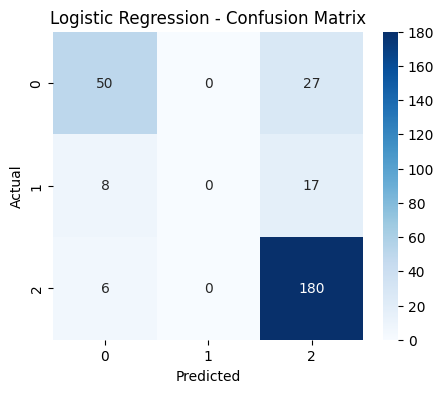

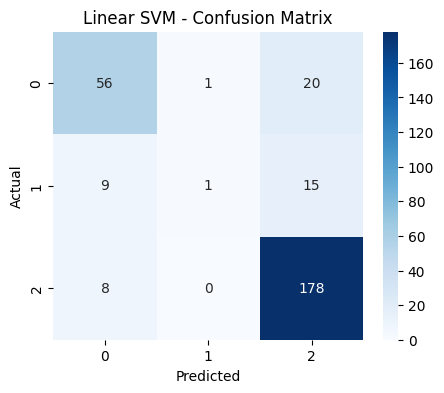

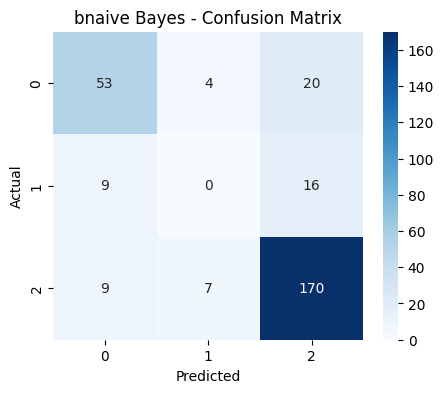

In [ ]:
for name, (acc, pred) in results.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**Model Evaluation**

In [ ]:
accuracy_results = {}
for name, (acc, pred_val) in results.items():
    accuracy_results[name] = acc

accuracy_df = pd.DataFrame(list(accuracy_results.items()),
                           columns=["Model","Accuracy"])

print(accuracy_df)

                 Model  Accuracy
0  Logistic Regression  0.798611
1           Linear SVM  0.815972
2         bnaive Bayes  0.774306


**MODEL COMPARISION**

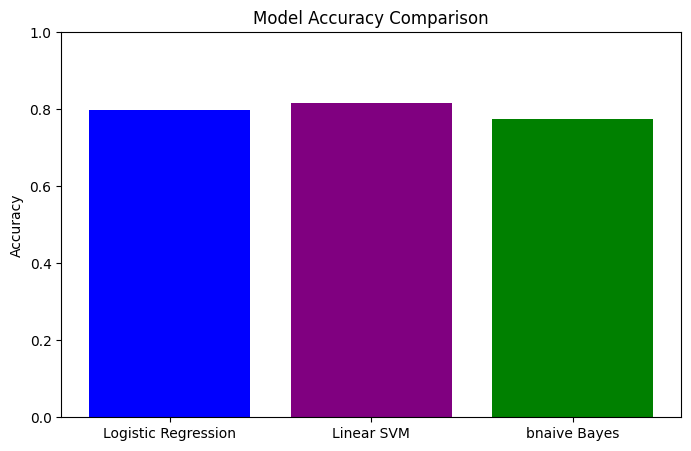

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [results[m][0] for m in results.keys()], color=['blue','purple','green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [ ]:
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

In [ ]:
pickle.dump(scaler, open("scaler1.pkl", "wb"))

In [ ]:
pickle.dump(models["Logistic Regression"], open("sentiment_model.pkl", "wb"))

In [ ]:
import pickle
tfidf = pickle.load(open("tfidf_vectorizer.pkl", "rb"))
scaler = pickle.load(open("scaler1.pkl", "rb"))
model = pickle.load(open("sentiment_model.pkl", "rb"))